# 🏥 Medication Cascade AI: Training Pipeline
This notebook demonstrates the complete machine learning workflow for detecting medication cascades using pharmacological overlaps and treatment timelines.

### 1. Install Dependencies & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("✅ Environment Ready")

### 2. Generate Synthetic Clinical Data
Since this is a standalone notebook, we will generate a dataset that mimics the real-world medication patterns used in the app.

In [13]:
def generate_data(n_samples=200):
    data = []
    # Cascade Case: Metformin (Side effect: Stomach Pain) -> Omeprazole (Treats: Stomach Pain)
    for i in range(n_samples // 2):
        data.append({'time_to_next': np.random.randint(2, 15), 'overlap': 1, 'label': 1}) # High risk
    
    # Safe Case: Albuterol -> Levothyroxine (No overlap)
    for i in range(n_samples // 2):
        data.append({'time_to_next': np.random.randint(30, 365), 'overlap': 0, 'label': 0}) # Low risk
        
    df = pd.DataFrame(data)
    return df.sample(frac=1).reset_index(drop=True)

df = generate_data()
print(f"Data generated: {len(df)} records")
df.head()

Data generated: 200 records


,time_to_next,overlap,label
0,341,0,0
1,194,0,0
2,6,1,1
3,8,1,1
4,11,1,1


### 3. Exploratory Data Analysis: Correlation Heatmap
We check how the features correlate with the final Cascade label.

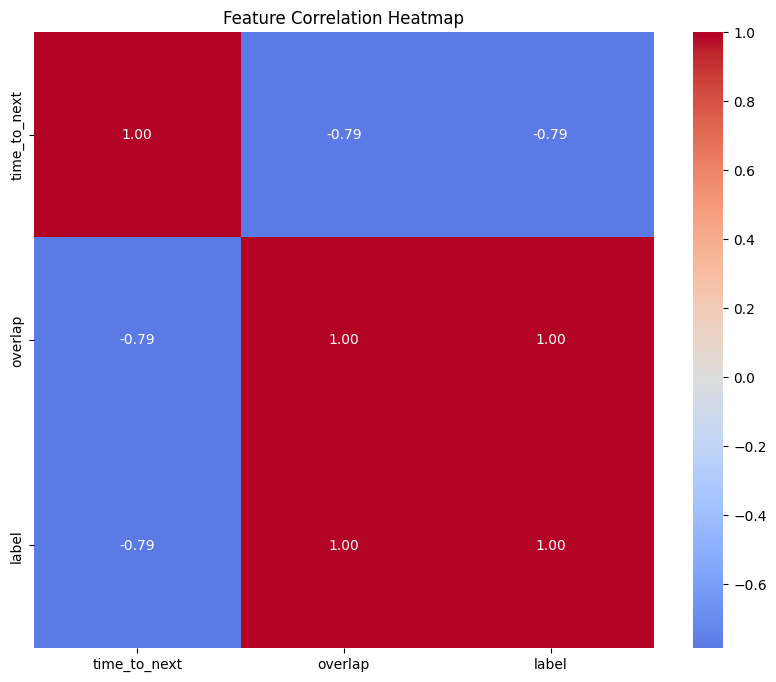

In [14]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

### 4. Feature Engineering Rationale
We use two primary features:
1. **Overlap (Binary)**: 1 if the second drug treats a side effect of the first.
2. **Time to Next (Continuous)**: Number of days between prescriptions. Shorter gaps usually indicate a cascade.

### 5. Train/Test Split

In [15]:
X = df[['time_to_next', 'overlap']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 160, Testing samples: 40


### 6. Multi-Model Comparison

In [16]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Logistic Regression": LogisticRegression(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Random Forest Accuracy: 1.0000
Logistic Regression Accuracy: 1.0000
Gradient Boosting Accuracy: 1.0000


### 7. Detailed Evaluation: Confusion Matrix Heatmap
We use a heatmap to visualize the accuracy of our predictions.

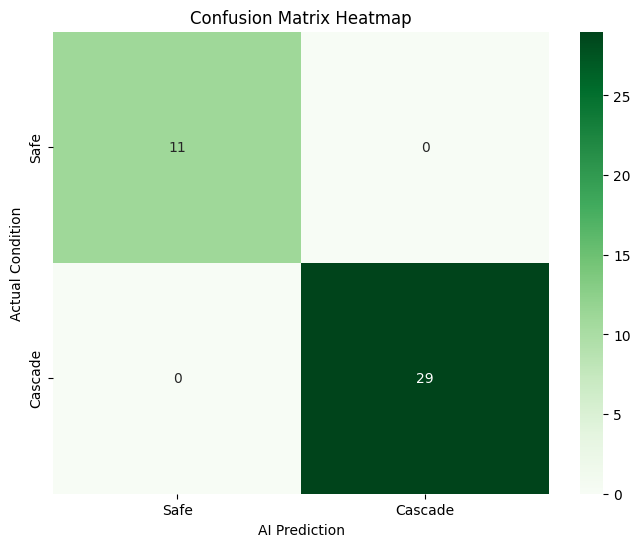


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        29

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [17]:
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Safe', 'Cascade'], yticklabels=['Safe', 'Cascade'])
plt.title('Confusion Matrix Heatmap')
plt.ylabel('Actual Condition')
plt.xlabel('AI Prediction')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### 8. Feature Importance
Which feature was most important for the AI's decision?

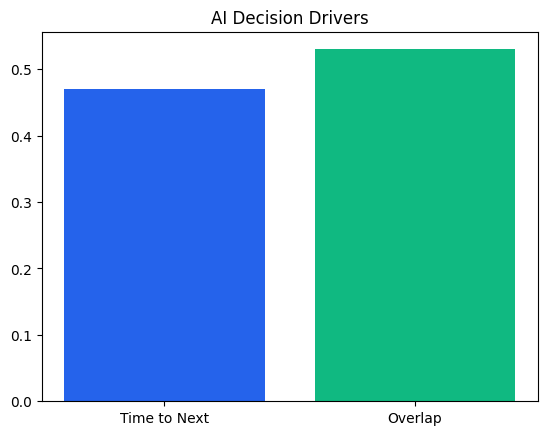

In [18]:
importances = best_model.feature_importances_
plt.bar(['Time to Next', 'Overlap'], importances, color=['#2563EB', '#10B981'])
plt.title('AI Decision Drivers')
plt.show()